# Prepare & Sample Gold Standard Dataset

## Overview
This notebook ingests data from AWS Athena and samples 2000 notes for a 'gold standard' dataset - a subset of our raw data that is human-annotated for subsequent model training.

It goes through several steps of preprocessing:
- Reshaping through AWS Athena (not run here. See [../reference/additional_needs_reshape.py]()). This combines records from the MMH `notes` table with the `tenure` table to make every note attributed to its relevant tenancy.

- Loading data from our newly made `additional_needs_notes_reshaped` table through Athena. [Link](#acquire-data).

- Acronym Exapansion. Finds commons acronyms in the note. These are then replaced with regexes with their expanded versions (human-verified). [Link](#expand-acronyms).

- Weak labelling using regexes. [Link](#weak-labeling-via-regex).

- Exploratory Data Analysis. [Link](#exploratory-data-analysis).

- Removes low-prevalence labels. [Link](#drop-rare-categories).

- Stratified Sampling using the regexes as a heuristic (45 examples per class - 40*45 = 1800, 1800 + 200 'zero match' classes add to 2000 notes). [Link](#stratified-sample-n2000).

- PII redaction. Strips Personally Identifiable Information (PII) from the gold standard set. Replaces names with autogenerated fake names. [Link](#pii-personally-identifiable-information-redaction).

- Pre-annotation. Uses the regexes to pre-annotate the notes with the correct span (the specific words, e.g. 'resident uses a wheelchair'). [Link](#pre-annotation).

- Exports to CSV and JSON. [Link](#export-sample-set).

**Note: Unredacted data is never persisted on the local device. This is intentional as it prevents data protection issues around storing resident data on local devices, but it means that re-running this file on different days will likely produce different results due to new notes being added to upstream data sources. Keep this in mind as your new reruns could overwrite previous exports.**


## Environment Setup

In [30]:
# Imports
import pandas as pd
import numpy as np
import json
import re
from dataclasses import dataclass

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from tqdm.notebook import tqdm
from pandarallel import pandarallel

import boto3
import awswrangler as wr

import nltk
from collections import Counter
from nltk.corpus import words

from presidio_analyzer import AnalyzerEngine, PatternRecognizer, Pattern
from presidio_anonymizer import AnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig
from faker import Faker

In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent / "src"))

from common.paths import RAW, PROCESSED
from common.graph_helpers import analyze_category_distribution_from_df, plot_cooccurrence_heatmap
from common.logging import setup_logger

In [32]:
@dataclass
class AwsConfig:
    aws_region = "eu-west-2"
    aws_profile = "data-platform-housing-prod"
    database_name = "housing-refined-zone"
    table_name = "additional_needs_notes_reshaped"

@dataclass
class Config:
    logger = setup_logger('preprocessing.sample_gold_standard')
    AWS = AwsConfig()

    random_state = 42
    target_total = 2000
    target_per_cat = 45

    # Paths
    taxonomy_path_v1 = PROCESSED / "taxonomy_autogen_v1.csv"
    taxonomy_path_v2 = PROCESSED / "taxonomy_autogen_v2.csv"
    output_gold_standard_json_path = PROCESSED / "gold_standard_sample.json"
    output_gold_standard_csv_path = PROCESSED / "gold_standard_sample.csv"
    regex_matches_path = PROCESSED / "full_dataset_regex_matches.csv"

    # PII entites to redact
    redact_entities = [
        "PERSON", 
        "EMAIL_ADDRESS", 
        "PHONE_NUMBER", 
        "DATE_TIME",
        "LOCATION",
        "UK_POSTCODE", 
        "CREDIT_CARD", 
        "IBAN_CODE", 
        "IP_ADDRESS",
        "URL"
    ]

config = Config()

In [33]:
# Tool setups

# NLTK
nltk.download('words')

# Pandarallel
pandarallel.initialize(progress_bar=True)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


[nltk_data] Downloading package words to /Users/arawat/nltk_data...
[nltk_data]   Package words is already up-to-date!


## Acquire Data
Get latest data from AWS Athena.

In [ ]:
def fetch_data_from_athena():
    session = boto3.Session(region_name=config.AWS.aws_region, profile_name=config.AWS.aws_profile)

    sql_query = f''' SELECT DISTINCT note_id, note_content, note_category, note_date
                    FROM "{config.AWS.database_name}".{config.AWS.table_name}
                    WHERE flag_no_matching_target = FALSE
                        AND flag_note_date_parse_failed = FALSE
                        AND flag_is_organisation = FALSE
                        AND flag_inactive = FALSE;
    '''

    return wr.athena.read_sql_query(sql_query, database=config.AWS.database_name, boto3_session=session, ctas_approach=False)

df = fetch_data_from_athena()

In [35]:
if not df['note_content'].str.startswith('[Category:').all():
    # Prevents this from running twice
    df['note_content'] = "[Category: " + df['note_category'] + "] " + df['note_content']
df.head()

,note_id,note_content,note_category
0,1e16e387-016b-a2a4-ced6-545940e8ab23,[Category: Tenancy Management] Call Summary; C...,Tenancy Management
1,246ad5cd-e5df-b342-ac8b-83f310f272d6,[Category: Tenancy Management] Applicant phone...,Tenancy Management
2,2b4dca8c-0aa5-f8e6-a629-d1b0f6cec646,[Category: Tenancy Management] Call Summary; C...,Tenancy Management
3,2f6e8f7a-615c-bd6e-b8b3-28ba2a4c64c3,[Category: Tenancy Management] Call Summary; C...,Tenancy Management
4,3d223195-6f1c-bdf3-96a5-57d3cc3c28f3,[Category: Tenancy Management] Call Summary; C...,Tenancy Management


## Expand Acronyms
Discover common acronyms (2-4 letter words that aren't in the English dictionary) and replace them with their expanded forms.

In [36]:
def get_most_common_acronyms(series: pd.Series, n: int = 100) -> list:
    # Load the standard English dictionary into a lookup set
    english_vocab = set(word.lower() for word in words.words())

    # Find 2-4 letter words (pre-compile for speed)
    acronym_pattern = re.compile(r'\b[a-z]{2,4}\b')
    
    acronym_counter = Counter()

    # Stream and update row-by-row
    for text in series.dropna():
        if isinstance(text, str):
            # Find short words and filter ones that aren't in the dictionary
            short_words = acronym_pattern.findall(text.lower())
            acronyms_only = [word for word in short_words if word not in english_vocab]
            
            # Batch update the counter
            acronym_counter.update(acronyms_only)

    return acronym_counter.most_common(n)

get_most_common_acronyms(df['note_content'], n=100)

[('tnt', 169264),
 ('has', 164408),
 ('lh', 61266),
 ('uk', 60468),
 ('gov', 50320),
 ('ms', 40816),
 ('asb', 39307),
 ('cb', 31606),
 ('hb', 29124),
 ('paid', 22696),
 ('sc', 18409),
 ('keys', 15146),
 ('rcc', 14889),
 ('cc', 14641),
 ('hsc', 14404),
 ('tel', 13849),
 ('says', 13312),
 ('ange', 12633),
 ('dd', 12483),
 ('doua', 12137),
 ('com', 12122),
 ('pls', 10954),
 ('rtb', 9723),
 ('auth', 9551),
 ('eo', 9219),
 ('cleo', 7622),
 ('nosp', 7304),
 ('co', 6583),
 ('wba', 5917),
 ('info', 5659),
 ('uhw', 5388),
 ('olu', 5181),
 ('nho', 5053),
 ('fobs', 4974),
 ('mpa', 4953),
 ('bacs', 4900),
 ('docs', 4742),
 ('mw', 4636),
 ('rec', 4582),
 ('ali', 4552),
 ('tnts', 4484),
 ('hh', 4447),
 ('appt', 4302),
 ('app', 4206),
 ('ntq', 4088),
 ('ncst', 3859),
 ('itv', 3813),
 ('uc', 3714),
 ('acc', 3574),
 ('ve', 3478),
 ('emre', 3324),
 ('gge', 3276),
 ('mmh', 3216),
 ('etc', 3053),
 ('acct', 2935),
 ('kaur', 2818),
 ('feb', 2775),
 ('org', 2726),
 ('tmo', 2720),
 ('uht', 2692),
 ('kofi', 26

### Replace acronyms
We looked at the common acronyms from the cell above and constructed a *normalisation dictionary*.

In [37]:
abbreviation_mapping = {
    # Hackney terms
    r'\bhsc\b': 'Hackney Service Centre',
    r'\bmmh\b': 'Manage My Home',
    r'\blbh\b': 'London Borough of Hackney',
    r'\brcc\b': 'Repairs Contact Centre',

    # Housing terms
    r'\btnt\b': 'tenant',
    r'\bclt\b': 'client',
    r'\btnts\b': 'tenants',
    r'\bl/h\b': 'leaseholder',
    r'\bh/o\b': 'housing officer',
    r'\btmo\b': 'Tenant Management Organisation',
    r'\bnho\b': 'neighbourhood housing officer',
    r'\bahm\b': 'area housing manager',
    r'\bhb\b': 'housing benefit',
    r'\bnosp\b': 'Notice of Seeking Possession',
    r'\bntq\b': 'Notice to Quit',
    r'\brtb\b': 'Right to Buy',
    r'\buc\b': 'Universal Credit',
    r'\basb\b': 'anti-social behaviour',
    r'\bdv\b': 'domestic violence',
    r'\bda\b': 'domestic abuse',

    # General terms
    r'\btel\b': 'telephone',
    r'\bdocs\b': 'documents',
    r'\bappt\b': 'appointment',
    r'\bacct\b': 'account',
    r'\bbacs\b': 'bank transfer',
    r'\binfo\b': 'information',
    r'\borg\b': 'organisation',
    r'\bsms\b': 'text message',
    r'\bmsg\b': 'message',
    r'\bcctv\b': 'camera',
    r'\bgp\b': 'general practitioner',
    r'\bpls\b': 'please',
    r'\brecd\b': 'received',
    r'\basap\b': 'as soon as possible',
    r'\bpls\b': 'please',
    r'\bcert\b': 'certificate',
    r'\bvm\b': 'voicemail',
}

In [38]:
acronym_substitution_patterns = [(re.compile(p, re.IGNORECASE), r) for p, r in abbreviation_mapping.items()]

def normalize_acronyms(text):
    if pd.isna(text):
        return text
    for pattern, replacement in acronym_substitution_patterns:
        text = pattern.sub(replacement, text)
    return text

df['note_content'] = df['note_content'].parallel_apply(normalize_acronyms)

## Weak Labeling via Regex
Apply the regex patterns from the taxonomy csv to assign 'weak labels' to the dataset.

In [39]:
taxonomy = pd.read_csv(config.taxonomy_path_v1)

In [40]:
category_regex_patterns = [(row.cat_label, re.compile(row.regex, re.IGNORECASE)) for row in taxonomy.itertuples()] # type: ignore

def flag_category_matches(series):
    """
    Apply all category regexes to a pandas Series of texts.
    Returns a DataFrame of boolean flags.
    """
    def apply_all_categories(text):
        return {label: bool(pattern.search(text)) for label, pattern in category_regex_patterns}

    results = series.fillna('').parallel_apply(apply_all_categories)
    return pd.DataFrame(results.tolist())

df = df.join(flag_category_matches(df['note_content']))

In [41]:
df.head()

,note_id,note_content,note_category,care_care_experienced,care_care_setting,care_has_caring_responsibility,care_social_care_involvement,cautions_asbo_or_injunction_obtained,cautions_dangerous_animals,cautions_visiting_requirements,...,mobility_service_need,property_level_property_adapted,property_level_disrepair_damp_mould,property_level_infestation,safety_risk_antisocial_behaviour,safety_risk_domestic_abuse,safety_risk_firerelated_risks,safety_risk_gas_capped,safety_risk_risk_of_exploitation,safety_risk_gang_activity_serious_youth_violence
0,1e16e387-016b-a2a4-ced6-545940e8ab23,[Category: Tenancy Management] Call Summary; C...,Tenancy Management,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,246ad5cd-e5df-b342-ac8b-83f310f272d6,[Category: Tenancy Management] Applicant phone...,Tenancy Management,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2b4dca8c-0aa5-f8e6-a629-d1b0f6cec646,[Category: Tenancy Management] Call Summary; C...,Tenancy Management,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2f6e8f7a-615c-bd6e-b8b3-28ba2a4c64c3,[Category: Tenancy Management] Call Summary; C...,Tenancy Management,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,3d223195-6f1c-bdf3-96a5-57d3cc3c28f3,[Category: Tenancy Management] Call Summary; C...,Tenancy Management,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [42]:
# Save out (without sensitive data)
df.drop('note_content', axis=1).to_csv(config.regex_matches_path, index=False)

## Exploratory Data Analysis
Analyze the distribution of the weak labels to understand class imbalances and inform stratified sampling. Analyse which labels co-occur.

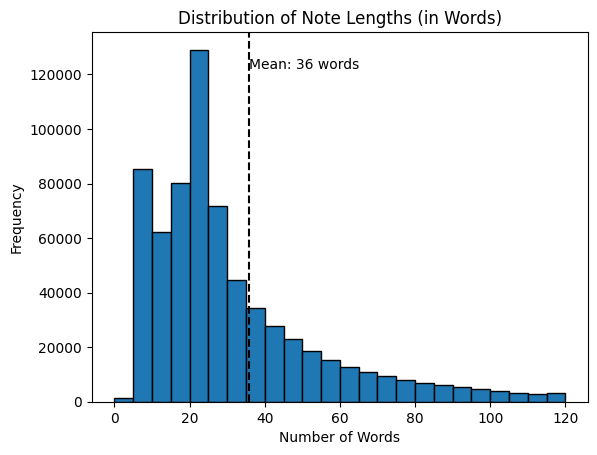

Mean: 35.92981501320516, Standard Deviation: 36.30183131793461, 95th percentile: 106.0
      bin   count
0     2.5    1546
1     7.5   85451
2    12.5   62349
3    17.5   80288
4    22.5  129067
5    27.5   71819
6    32.5   44723
7    37.5   34359
8    42.5   27945
9    47.5   22846
10   52.5   18729
11   57.5   15222
12   62.5   12733
13   67.5   10883
14   72.5    9272
15   77.5    7917
16   82.5    6832
17   87.5    6091
18   92.5    5442
19   97.5    4539
20  102.5    4013
21  107.5    3318
22  112.5    2944
23  117.5    3112


In [ ]:
def display_note_lengths_hist(df):
    # Length of notes in words (histogram)
    note_length_words = df['note_content'].fillna('').str.split().apply(len)
    plot_lengths = note_length_words[note_length_words <= 120] # Cut off outliers to fix graph size (over 95th percentile)

    # Histogram of note lengths
    counts, bins = np.histogram(plot_lengths, bins=24) # Bin size of 5

    # Convert bin edges into bar positions and widths
    bin_centres = (bins[:-1] + bins[1:]) / 2
    bin_widths = np.diff(bins)

    plt.bar(bin_centres, counts, width=bin_widths, edgecolor='black')

    # Mean + SD + 95th percentile
    mean_val = note_length_words.mean()
    standard_dev = note_length_words.std()
    p = np.percentile(note_length_words, 95)

    plt.axvline(mean_val, color='black', linestyle='--')
    plt.text(mean_val, plt.ylim()[1] * 0.9, f'Mean: {mean_val:.0f} words')

    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.title('Distribution of Note Lengths (in Words)')
    plt.show()

    print(f'Mean: {mean_val}, Standard Deviation: {standard_dev}, 95th percentile: {p}')

    return bin_centres, counts


bin_centres, counts = display_note_lengths_hist(df)
print(pd.DataFrame(zip(bin_centres, counts), columns=['bin', 'count']))

,label,frequency,IRLbl
0,property_level_disrepair_damp_mould,56375,1.000000
1,safety_risk_antisocial_behaviour,32477,1.735844
2,property_level_infestation,5415,10.410896
3,health_mental_health,4794,11.759491
4,life_events_temporary,4196,13.435415
5,cautions_verbal_abuse_or_threat_of,3610,15.616343
6,safety_risk_domestic_abuse,3116,18.092105
7,health_substance_misuse,2852,19.766830
8,care_social_care_involvement,1844,30.572126
9,safety_risk_firerelated_risks,1748,32.251144


,Metric,Value
0,MeanIR,1637.66
1,MaxIR,56375.00
2,CVIR,5.30


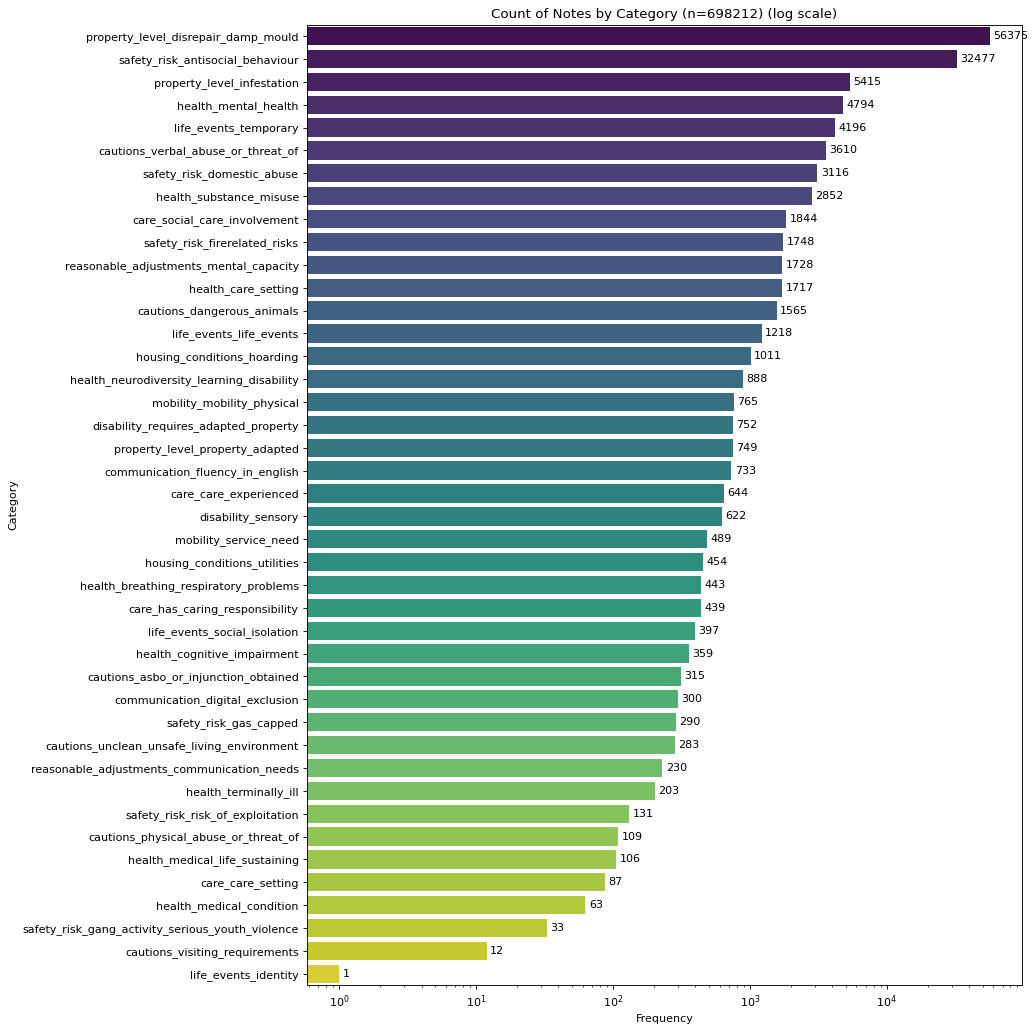

In [16]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_df(df.drop(columns=['note_id', 'note_content', 'note_category']), taxonomy)
display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)

In [17]:
# Number of notes that have at least one category match
bool_cols = df.select_dtypes(include=["bool"])
true_row_count = bool_cols.any(axis=1).sum()
print("%.2f" % (true_row_count/len(df) * 100) + "%")

16.71%


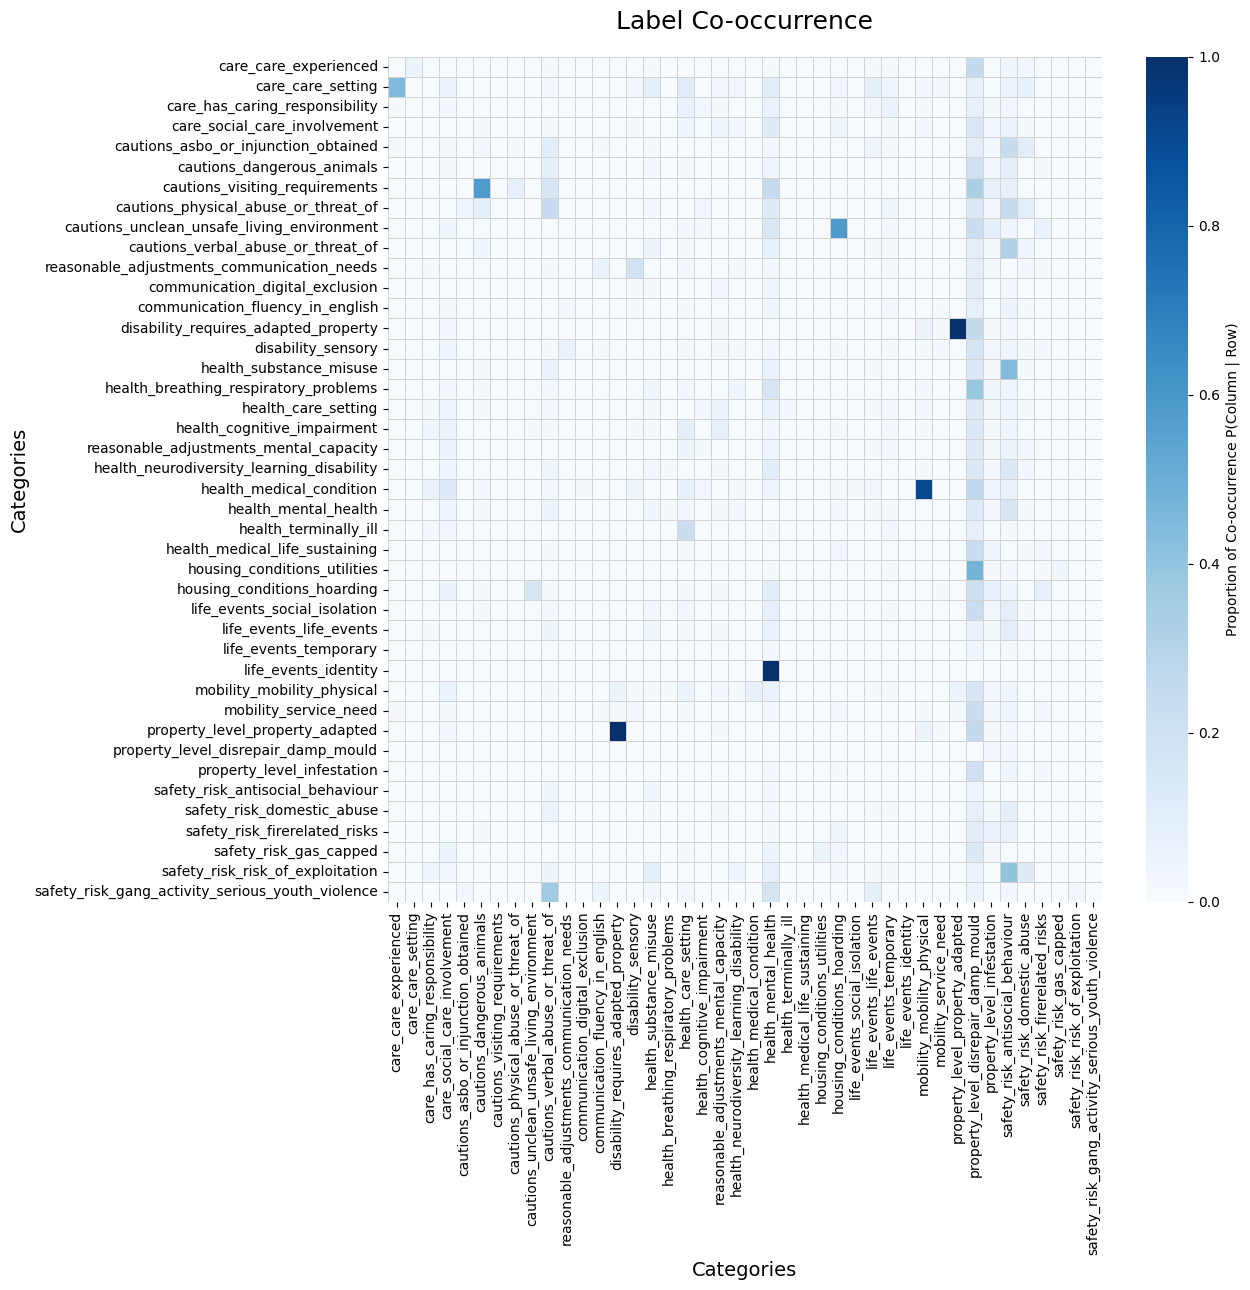

<Axes: title={'center': 'Label Co-occurrence'}, xlabel='Categories', ylabel='Categories'>

In [18]:
plot_cooccurrence_heatmap(df, taxonomy)

### Drop rare categories
Based on the EDA, drop categories to address class imbalance and ensure sufficient representation for sampling. Dropped categories will only rely on regex instead.

In [19]:
df_v2 = df.copy()
taxonomy_v2 = taxonomy.copy()

dropped_categories = [
    'life_events_identity', # Only one hit. Should drop.
    'cautions_visiting_requirements', # 12 hits
    'safety_risk_gang_activity_serious_youth_violence', # 33 hits
]

df_v2.drop(columns=dropped_categories, inplace=True)
mask = taxonomy_v2['cat_label'].isin(dropped_categories)
taxonomy_v2 = taxonomy_v2[~mask].reset_index(drop=True)
taxonomy_v2.to_csv(config.taxonomy_path_v2, index=False)

taxonomy_v2.head()

,high_level_category,category_description,values_hint,cat_label,regex
0,Care,Care experienced,"['Care leaver', 'Care experienced (under 25)']",care_care_experienced,\bcare experienced\b|\bcare leaver\b|\baged ou...
1,Care,Care setting,"['Fostered', 'Social care']",care_care_setting,\bfostered\b|\bfoster care\b|\bfoster placemen...
2,Care,Has caring responsibility,"['Formal', 'Informal']",care_has_caring_responsibility,\bformal carer\b|\bregistered carer\b|\bcarer....
3,Care,Social care involvement,"['Adult Social Care', ""Children's Social Care""]",care_social_care_involvement,\bsocial care\b|\bcare package\b|\bcare plan\b...
4,Cautions,ASBO or injunction obtained,"['ASBO', 'Injunction']",cautions_asbo_or_injunction_obtained,\bASBO\b|\binjunction\b|\bcivil injunction\b|\...


In [20]:
del df # memory saving

### Compare class imbalance
Compare the class imbalance before and after combining/dropping categories to assess the impact on the dataset.

,label,frequency,IRLbl
0,property_level_disrepair_damp_mould,56375,1.000000
1,safety_risk_antisocial_behaviour,32477,1.735844
2,property_level_infestation,5415,10.410896
3,health_mental_health,4794,11.759491
4,life_events_temporary,4196,13.435415
5,cautions_verbal_abuse_or_threat_of,3610,15.616343
6,safety_risk_domestic_abuse,3116,18.092105
7,health_substance_misuse,2852,19.766830
8,care_social_care_involvement,1844,30.572126
9,safety_risk_firerelated_risks,1748,32.251144


,Metric,Value
0,MeanIR,153.86
1,MaxIR,894.84
2,CVIR,1.28


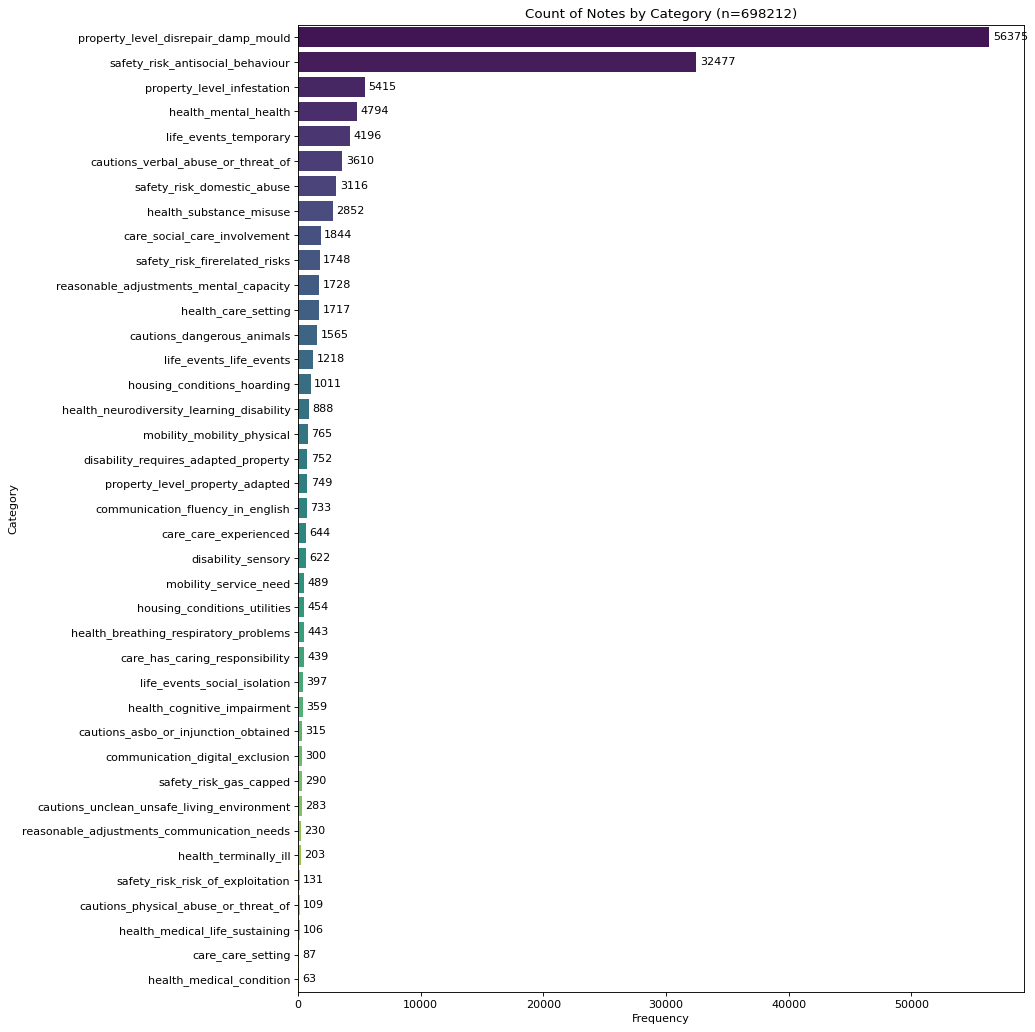

In [21]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_df(df_v2.drop(columns=['note_id', 'note_content', 'note_category']), taxonomy_v2, log_scale=False)
display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)

## Construct Gold Standard Set
Uses *iterative random sampling*, which is a common technique to perform stratified sampling on a multi-label dataset. We start by choosing n=45 examples of the least prevalent class and then continue with the rest of the labels, removing examples that have already been sampled. This helps to balance the dataset where examples can have multiple labels.

### Stratified Sample (n=2000)
Perform stratified sampling based on the weak labels to create a balanced gold standard dataset of 2000 records for manual annotation.

In [22]:
# Get unflagged records - zero category matches.
df_v2['unflagged'] = ~df_v2[taxonomy_v2['cat_label']].any(axis=1)
df_v2['unflagged'].value_counts()

unflagged
True     581589
False    116623
Name: count, dtype: int64

In [23]:
def sample_gold_standard(df, taxonomy):
    sampled_data = []
    sampled_ids = set()

    # Sample categories by least prevalent (up to config.target_per_cat)
    category_counts = df[taxonomy['cat_label']].sum().sort_values(ascending=True)
    for cat in category_counts.index:
        pool = df[df[cat] & ~df['note_id'].isin(sampled_ids)] # In the category and not already sampled
        n = min(len(pool), config.target_per_cat)
        if n > 0:
            sample = pool.sample(n=n, random_state=config.random_state) # Random sample
            sampled_data.append(sample)
            sampled_ids.update(sample['note_id'].tolist())

    # Sample unflagged (non-category matches) records
    pool = df[df['unflagged'] & ~df['note_id'].isin(sampled_ids)]
    n = min(len(pool), config.target_total - len(sampled_ids))
    if n > 0:
        sample = pool.sample(n=n, random_state=config.random_state)
        sampled_data.append(sample)
        sampled_ids.update(sample['note_id'].tolist())

    # Combine and shuffle
    return pd.concat(sampled_data).sample(frac=1, random_state=config.random_state).reset_index(drop=True)

In [24]:
final_sample = sample_gold_standard(df_v2, taxonomy_v2)
final_sample.drop(columns=['note_id', 'note_content', 'note_category']).sum().sort_values()

cautions_physical_abuse_or_threat_of           45
health_terminally_ill                          46
health_medical_condition                       46
safety_risk_risk_of_exploitation               47
care_care_setting                              48
communication_digital_exclusion                48
health_medical_life_sustaining                 48
health_breathing_respiratory_problems          48
safety_risk_gas_capped                         49
cautions_asbo_or_injunction_obtained           51
reasonable_adjustments_communication_needs     51
housing_conditions_utilities                   51
life_events_social_isolation                   51
cautions_unclean_unsafe_living_environment     52
health_cognitive_impairment                    54
communication_fluency_in_english               55
mobility_service_need                          56
health_neurodiversity_learning_disability      56
life_events_life_events                        60
safety_risk_firerelated_risks                  61


In [25]:
del df_v2 # Memory saving

### Compare class imbalance
Compare the class imbalance in the gold standard set to the original dataset to evaluate the effectiveness of the sampling strategy.

,label,frequency,IRLbl
0,property_level_disrepair_damp_mould,330,1.000000
1,unflagged,245,1.346939
2,safety_risk_antisocial_behaviour,193,1.709845
3,health_mental_health,141,2.340426
4,health_care_setting,104,3.173077
5,cautions_verbal_abuse_or_threat_of,98,3.367347
6,property_level_property_adapted,96,3.437500
7,mobility_mobility_physical,96,3.437500
8,disability_requires_adapted_property,96,3.437500
9,care_social_care_involvement,94,3.510638


,Metric,Value
0,MeanIR,5.06
1,MaxIR,7.33
2,CVIR,0.34


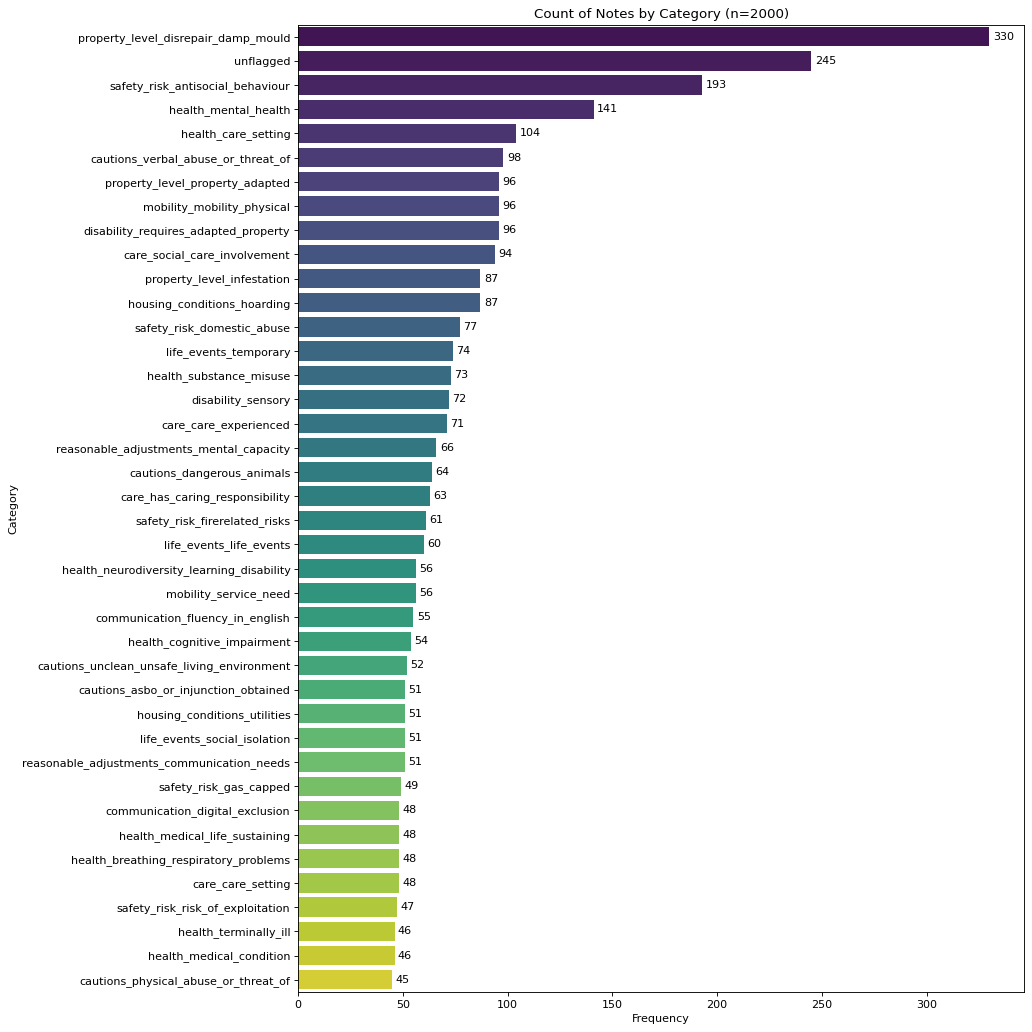

In [26]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_df(final_sample.drop(columns=['note_id', 'note_content', 'note_category']), taxonomy_v2, log_scale=False)
display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)

### PII (Personally-Identifiable Information) Redaction
Apply PII redaction techniques to the gold standard dataset to ensure privacy and compliance with GDPR before manually annotating.

In [27]:
def clean_data(df):
    # Anonymise & track names that were replaced
    def anonymize_and_extract_spans(text):
        if not isinstance(text, str):
            return pd.Series({'note_content': text, 'fake_name_spans': []})
            
        # Analyze
        results = analyzer.analyze(text=text, entities=config.redact_entities, language='en')
        
        # Anonymize
        anonymized = anonymizer.anonymize(
            text=text,
            analyzer_results=results, # type: ignore
            operators=operators
        )
        
        fake_spans = []
        for item in anonymized.items:
            if item.entity_type == 'PERSON':
                # Highlight replaced names as fake
                fake_spans.append({
                    'start': item.start,
                    'end': item.end,
                    'text': item.text, 
                    'labels': ['Pseudonym'] 
                })
        
        return pd.Series({
            'note_content': anonymized.text,
            'fake_name_spans': fake_spans
        })

    # Set up engines
    fake = Faker('en')
    Faker.seed(config.random_state)

    analyzer = AnalyzerEngine()
    anonymizer = AnonymizerEngine()

    # Regex matcher for UK postcodes
    uk_postcode_pattern = Pattern(
        name="uk_postcode_regex", 
        regex=r"\b([Gg][Ii][Rr] 0[Aa]{2})|((([A-Za-z][0-9]{1,2})|(([A-Za-z][A-Ha-hJ-Yj-y][0-9]{1,2})|(([A-Za-z][0-9][A-Za-z])|([A-Za-z][A-Ha-hJ-Yj-y][0-9][A-Za-z]?))))\s?[0-9][A-Za-z]{2})\b", 
        score=0.85
    )
    uk_postcode_recognizer = PatternRecognizer(
        supported_entity="UK_POSTCODE", 
        patterns=[uk_postcode_pattern]
    )
    analyzer.registry.add_recognizer(uk_postcode_recognizer)

    # Replace names with fake names
    consistent_name_map = {}
    def get_consistent_fake_name(text):
        if text not in consistent_name_map:
            consistent_name_map[text] = fake.name()
        return consistent_name_map[text]

    # Define operator for each entity type
    operators = {
        "PERSON": OperatorConfig("custom", {"lambda": get_consistent_fake_name}),
        "DEFAULT": OperatorConfig("replace") # Automatically replaces with e.g., <PHONE_NUMBER>
    }

    tqdm.pandas() # Enable pandas progress_apply (for progress bar)
    scrubbed_df = df.copy()
    scrubbed_df[['note_content', 'fake_name_spans']] = scrubbed_df['note_content'].progress_apply(anonymize_and_extract_spans)
    return scrubbed_df

In [28]:
scrubbed_df = clean_data(final_sample)
scrubbed_df.head()

  0%|          | 0/2000 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Pre-Annotation
Pre-annotate the category spans, pseudonyms, and role (e.g. tenant, leaseholder). This will help speed up manual annotation.

We use regexes for Additional Need categories and for roles. We use the `fake_name_spans` generated in the previous section to highlight automatically generated pseudonyms as names.

In [ ]:
def generate_label_studio_json(df):
    # Construct regexes for ANs & roles & compile
    person_role_regex = r"(?i)\b(tenant|tenants|leaseholder|leaseholders|resident|residents|child|children|son|daughter|partner|wife|husband|mother|father|caller|applicant|neighbour|neighbor|neighbours|neighbor)\b" # common housing roles
    compiled_role_regex = re.compile(person_role_regex)
    compiled_category_regex = {row.cat_label: re.compile(row.regex) for row in taxonomy_v2.itertuples()} # type: ignore

    # Loop through dataframe rows
    label_studio_tasks = []
    for index, row in tqdm(df.iterrows()):
        note_content = str(row['note_content'])
        note_id = str(row['note_id'])
        
        identified_labels = []
        
        # --- AN Tags ---
        for cat_key, compiled_regex in compiled_category_regex.items():
            for match in compiled_regex.finditer(note_content):
                identified_labels.append({
                    "from_name": "need_labels",  # Needs to match Label Studio XML
                    "to_name": "text",
                    "type": "labels",
                    "value": {
                        "start": match.start(), # Extract the specific span - didn't do with the whole dataset as it is expensive.
                        "end": match.end(),
                        "text": match.group(),
                        "labels": [cat_key]
                    }
                })

        # --- Role Labels ---
        for match in compiled_role_regex.finditer(note_content):
            identified_labels.append({
                "from_name": "entity_labels",  # Needs to match Label Studio XML
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": match.start(),
                    "end": match.end(),
                    "text": match.group(),
                    "labels": ["Person Role"]
                }
            })

        # --- Fake name Spans (Presidio) ---
        for span in row['fake_name_spans']:
            identified_labels.append({
                "from_name": "entity_labels", # Needs to match Label Studio XML
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": span['start'],
                    "end": span['end'],
                    "text": span['text'],
                    "labels": span['labels']
                }
            })
        
        # --- Construct label studio task ---
        task = {
            "data": {
                "note_content": note_content,
                "id": note_id
            },
            "predictions": [{
                "model_version": "pre_annotated",
                "score": 1.0,
                "result": identified_labels
            }]
        }
        
        label_studio_tasks.append(task)
    return label_studio_tasks

In [ ]:
label_studio_tasks = generate_label_studio_json(scrubbed_df)
len(label_studio_tasks)

0it [00:00, ?it/s]

2000

In [ ]:
label_studio_tasks[1]

{'data': {'note_content': "[Category: tenureManagement] Ending Tenancy  IGNORE PREVIOUS NOTE. I Spoke to Housing Officer for 9 Wilde Close where the tenant has been moved to. Unable to end current tenancy unless new sign up is done at Gabrielle Davis, Gina Moore the housing officer for Abigail Shaffer close confirmed he spoke to the Mr Connie Lawrence's sister who confirmed Cristian Santos is currently in hospital and is unable to do much due to his condition.   tenant's sister stated she would like to collect items from the property but did not confirm the items she wishes to collect (tenant's sister has had the keys for 83 Fellows Court <DATE_TIME> and did not attend the property)  tenant's sister will call me to arrange a time and date to collect items. \n\nMr Daniel Wagner is a severe hoarder the property is not in good condition and there are no visible valuables (pictures taken)",
  'id': '3846587c-fcd0-470a-b84a-5c87477b2d31'},
 'predictions': [{'model_version': 'pre_annotated',

### Export sample set

In [ ]:
# Annotated examples
with open(config.output_gold_standard_json_path, "w") as f:
    json.dump(label_studio_tasks, f, indent=2)

In [ ]:
# Data without annotations
scrubbed_df.to_csv(config.output_gold_standard_csv_path, index=False) 